In [16]:
import os
import random
import time

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

In [17]:
# settings
env_id  = "CartPole-v1"

# number of environments to run in parallel
num_envs = 4

# total number of timesteps for training over multiple episodes
total_timesteps = 100_000

# adam learning rate
learning_rate = 8e-4

# discount factor
gamma = 0.99

# optional: set seed for reproducibility
# seed = 123
seed = None

# entropy coefficient for loss
entropy_weight = 0.01

# value function coefficient for loss
value_weight = 0.25

# max L2-norm for gradient clipping
max_norm = 0.5

# where to save videos
video_path = "videos_a2c_cartpole"

In [18]:
# will encapsulate in lambda later
def make_env(env_id, capture_video, seed=None):
    if capture_video:
        env = gym.make(env_id, render_mode="rgb_array")
        env = gym.wrappers.RecordVideo(env, video_path,
            episode_trigger=lambda episode: True)
        # ensure it records all episodes, by default it only records every 1000th
    else:
        env = gym.make(env_id)
    env = gym.wrappers.RecordEpisodeStatistics(env)

    # To get reproducible sampling of actions, a seed can be set with env.action_space.seed(123)
    if seed is not None:
        env.action_space.seed(seed)
    return env

In [19]:
class ActorCritic(nn.Module):
  def __init__(self, envs, n_hidden=128):
    super().__init__()
    self.network = nn.Sequential(
      nn.Linear(envs.single_observation_space.shape[0], n_hidden),
      nn.ReLU(),
    )

    # Actor / Policy Head
    self.actor = nn.Linear(n_hidden, envs.single_action_space.n)

    # Critic / Value Head
    self.critic = nn.Linear(n_hidden, 1)

  def forward(self, x):
    x = self.network(x)
    return self.actor(x), self.critic(x)

In [20]:
# make environments
envs = gym.vector.SyncVectorEnv([
    lambda: make_env(
        env_id,
        False,
        seed if seed is None else seed + i) for i in range(num_envs)
])

In [21]:
# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
# make neural network
ac_network = ActorCritic(envs).to(device)
optimizer = optim.Adam(ac_network.parameters(), lr=learning_rate)

In [23]:
# sample an action from logits
#Categorical:Create a categorical distribution object that can be used to sample from the distribution, compute probabilities or log probabilities, etc.
def sample_action(logits):
  dist = Categorical(logits=logits)
  return dist.sample()

In [24]:
# compute entropy for loss regularization
def compute_entropy_and_log_prob(logits, actions):
  dist = Categorical(logits=logits)
  return dist.entropy().mean(), dist.log_prob(actions)

# compute entropy for loss regularizaation
def compute_entropy(policy_logits):
    probs = F.softmax(policy_logits, dim=-1)  # Convert logits to probabilities
    log_probs = F.log_softmax(policy_logits, dim=-1)  # Log probabilities
    entropy = -torch.sum(probs * log_probs, dim=-1)  # Compute entropy
    return entropy.mean(), log_probs  # Take mean over batch if needed

In [25]:
def np2torch(a, dtype=torch.float32, device=device):
  return torch.as_tensor(a, dtype=dtype, device=device)

In [26]:
# training loop
episode_returns = []
losses = []

In [ ]:
start_time = time.time()
obs, _ = envs.reset(seed=seed)
autoreset = np.zeros(num_envs, dtype=bool)

for global_step in range(total_timesteps):

  # get model output
  action_logits, value = ac_network(np2torch(obs))

  # select action based on current policy
  actions = sample_action(action_logits)
  actions_np = actions.detach().cpu().numpy()

  # take a step in the environment
  next_obs, rewards, dones, truncateds, infos = envs.step(actions_np)

  # record returns for plotting
  for i, (done, truncated) in enumerate(zip(dones, truncateds)):
    if done or truncated:
      ret = infos['episode']['r'][i]
      episode_returns.append(ret)
      print(f"global_step={global_step}, episode={len(episode_returns)}, episode_return={ret}")

  # don't forget
  # note: if autoreset is true, next_obs is s(1)
  obs = next_obs

  ### training! ###
  mask = np.logical_not(autoreset)
  value_ = value[mask]
  obs_ = obs[mask]
  actions_ = actions[mask]
  action_logits_ = action_logits[mask]
  rewards_ = rewards[mask]
  next_obs_ = next_obs[mask]
  dones_ = dones[mask]

  # value loss
  with torch.no_grad():
    _, value_next = ac_network(np2torch(next_obs_))
    td_target = np2torch(rewards_.flatten()) + \
      gamma * np2torch(1 - dones_.flatten()) * value_next.flatten()
  pred = value_.flatten()
  value_loss = F.mse_loss(pred, td_target)

  # policy loss
  # entropy, log_probs = compute_entropy(action_logits_)
  entropy, selected_log_probs = compute_entropy_and_log_prob(
      action_logits_, actions_)
  advantage = td_target - value_
  # log_probs[:, actions]
  # selected_log_probs = log_probs.gather(1, actions_.unsqueeze(1)).squeeze(1)

  # print("log_probs.shape:", log_probs.shape)
  # print("actions_.shape:", actions_.shape)
  # print("selected_log_probs.shape:", selected_log_probs.shape

  policy_loss = -torch.mean(selected_log_probs * advantage.detach())

  # total loss
  loss = policy_loss - entropy_weight * entropy + value_weight * value_loss
  losses.append(loss.item())

  if global_step % 100 == 0:
    print("steps per second:", int(global_step / (time.time() - start_time)))

  # gradient descent step
  optimizer.zero_grad()
  loss.backward()
  # nn.utils.clip_grad_norm_(ac_network.parameters(), max_norm)
  optimizer.step()

  # update autoreset
  autoreset = np.logical_or(dones, truncateds)

  # let's just break if the last 10 episodes had max reward
  if len(episode_returns) > 10 and np.all(np.equal(episode_returns[-10:], 500)):
    print("max reward achieved!")
    break

steps per second: 0
global_step=9, episode=1, episode_return=10.0
global_step=9, episode=2, episode_return=10.0
global_step=9, episode=3, episode_return=10.0
global_step=27, episode=4, episode_return=28.0
global_step=34, episode=5, episode_return=24.0
global_step=39, episode=6, episode_return=29.0
global_step=47, episode=7, episode_return=19.0
global_step=48, episode=8, episode_return=13.0
global_step=50, episode=9, episode_return=40.0
global_step=63, episode=10, episode_return=15.0
global_step=64, episode=11, episode_return=15.0
global_step=73, episode=12, episode_return=22.0
global_step=78, episode=13, episode_return=38.0
global_step=79, episode=14, episode_return=15.0
global_step=85, episode=15, episode_return=11.0
global_step=86, episode=16, episode_return=21.0
global_step=95, episode=17, episode_return=15.0
global_step=98, episode=18, episode_return=19.0
steps per second: 222
global_step=103, episode=19, episode_return=17.0
global_step=103, episode=20, episode_return=16.0
global_s

In [13]:
def smooth(x, a=0.1):
    y = [x[0]]
    for xi in x[1:]:
        yi = a * xi + (1 - a) * y[-1]
        y.append(yi)
    return y

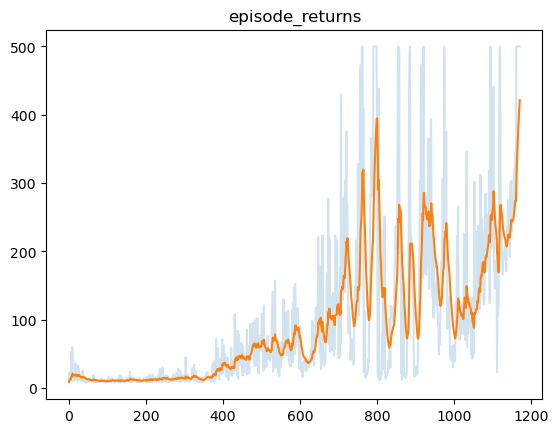

In [14]:
plt.plot(episode_returns, alpha=0.2)
plt.plot(smooth(episode_returns))
plt.title("episode_returns");
plt.show();

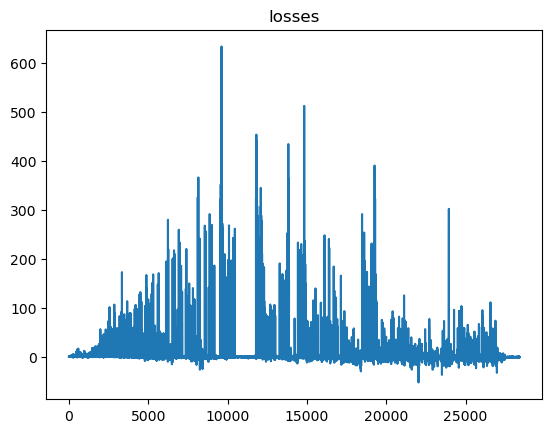

In [15]:
plt.plot(losses)
plt.title("losses");
plt.show();

In [ ]:
# save model
model_path = "a2c_cartpole.pth"
torch.save(ac_network.state_dict(), model_path)

In [ ]:
# load model for eval
envs_eval = gym.vector.SyncVectorEnv([lambda: make_env(env_id, True)])
model = ActorCritic(envs_eval).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

In [ ]:
# evaluate model
n_episodes_eval = 10
eval_returns = np.zeros(n_episodes_eval)
obs, _ = envs_eval.reset()
for i in range(n_episodes_eval):
  episode_done = False
  while not episode_done:
    action_logits, _ = model(np2torch(obs))

    # select action based on current policy
    actions = sample_action(action_logits)
    actions_np = actions.detach().cpu().numpy()

    # take a step in the environment
    obs, rewards, dones, truncateds, infos = envs_eval.step(actions_np)

    if dones[0] or truncateds[0]:
      G = infos['episode']['r'][0]
      eval_returns[i] = G
      episode_done = True
      print(f"episode={i}, return={G}")

envs_eval.close()

In [ ]:
# plot the eval returns distribution
plt.hist(eval_returns)
plt.title("Eval Returns")
plt.show();

In [ ]:
# prompt: display video in colab notebook with filename "videos/rl-video-episode-0.mp4"

from IPython.display import HTML
from base64 import b64encode

mp4 = open(f'{video_path}/rl-video-episode-0.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=qsKxUjkGj_Qk9wyS1St9Jw&n=A2C+Cartpole)